
# Deep Reinforcement Learning — Convergence Tutorial

**Topic:** Practice notebook for the convergence supplement  
**Course:** Deep Reinforcement Learning  
**Instructor:** Mustafa Özger, Aalborg University

This notebook is designed to help you practice the main ideas behind **convergence** in machine learning and reinforcement learning.

## What you should learn
After working through this notebook, you should be able to:

1. interpret convergence in optimization,
2. see how learning rate affects gradient descent,
3. understand why stochastic gradients fluctuate,
4. view Bellman updates as a fixed-point iteration,
5. observe convergence behavior in tabular Q-learning,
6. explain why deep RL and MARL are harder to analyze.

## How to use this notebook
Each section contains:
- a short recap,
- runnable code,
- small questions and exercises.

Try to **predict the result before running** each experiment.


## 1. Setup
We import standard Python tools only. No external RL library is needed.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7)


Matplotlib is building the font cache; this may take a moment.



## 2. Warm-up: what does convergence mean?

In optimization, convergence usually means that the parameter sequence
\[
\theta_0, \theta_1, \theta_2, \ldots
\]
moves toward a point that minimizes or approximately minimizes the loss.

In RL, convergence can mean different things:
- the **value estimates** stabilize,
- the **policy** stops changing much,
- the **return curve** plateaus,
- the algorithm approaches a **fixed point** of a Bellman operator.

A key warning:

> A flat training curve does **not always** mean correct convergence.  
> It can also mean bad local behavior, lack of exploration, or unstable cancellation.



## 3. Exercise 1 — Gradient descent on a simple convex function

Consider the quadratic loss
\[
f(x) = (x-3)^2.
\]
Its gradient is
\[
\nabla f(x) = 2(x-3).
\]

The gradient descent update is
\[
x_{k+1} = x_k - \eta \, 2(x_k-3),
\]
where \(\eta\) is the learning rate.

### Task
Run the cell and compare what happens for different learning rates:
- very small \(\eta\),
- reasonable \(\eta\),
- too large \(\eta\).


lr=0.05: final x=2.425682, final loss=3.298416e-01
lr= 0.3: final x=3.000000, final loss=8.112964e-19
lr=0.95: final x=3.574318, final loss=3.298416e-01


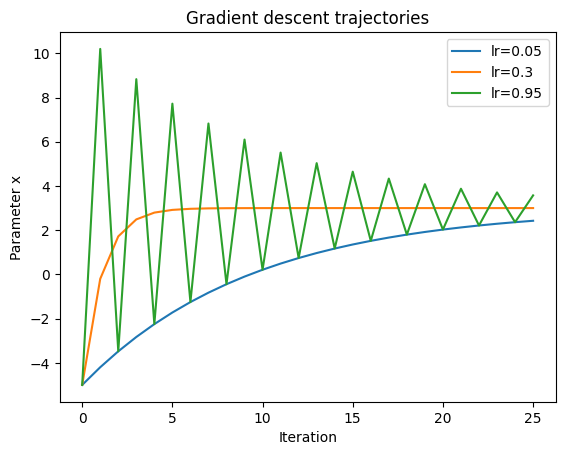

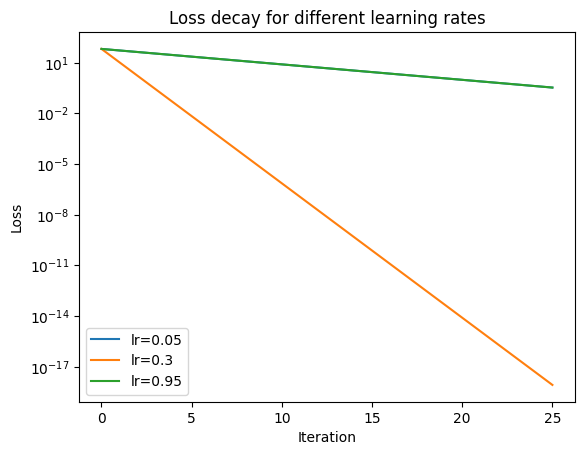

In [2]:

def f(x):
    return (x - 3.0) ** 2

def grad_f(x):
    return 2.0 * (x - 3.0)

def gradient_descent(x0, lr, steps):
    xs = [x0]
    for _ in range(steps):
        x = xs[-1]
        xs.append(x - lr * grad_f(x))
    return np.array(xs)

x0 = -5.0
steps = 25
learning_rates = [0.05, 0.3, 0.95]

trajectories = {lr: gradient_descent(x0, lr, steps) for lr in learning_rates}

for lr, xs in trajectories.items():
    print(f"lr={lr:>4}: final x={xs[-1]:.6f}, final loss={f(xs[-1]):.6e}")

for lr, xs in trajectories.items():
    plt.plot(xs, label=f"lr={lr}")
plt.xlabel("Iteration")
plt.ylabel("Parameter x")
plt.title("Gradient descent trajectories")
plt.legend()
plt.show()

for lr, xs in trajectories.items():
    plt.plot([f(x) for x in xs], label=f"lr={lr}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss decay for different learning rates")
plt.yscale("log")
plt.legend()
plt.show()



### Discussion
You should see three regimes:

- **Small learning rate:** stable but slow convergence.
- **Moderate learning rate:** fast and stable convergence.
- **Large learning rate:** oscillation or divergence.

For this simple quadratic, convergence depends strongly on the step size.

### Mini-question
Why is the “best” learning rate problem-dependent?  
Write your answer in one or two sentences below.


In [3]:

# Write your answer here
answer_q1 = ""
print("Your answer:", answer_q1)


Your answer: 



## 4. Exercise 2 — Stochastic gradient descent and noisy convergence

In practice, deep learning usually does **not** use the exact full gradient.
Instead, we use minibatches, which give a noisy estimate of the gradient.

We simulate that by adding Gaussian noise:
\[
g_k = 2(x_k-3) + \text{noise}.
\]

### Task
Run the experiment and compare:
- deterministic gradient descent,
- stochastic gradient descent with small noise,
- stochastic gradient descent with larger noise.


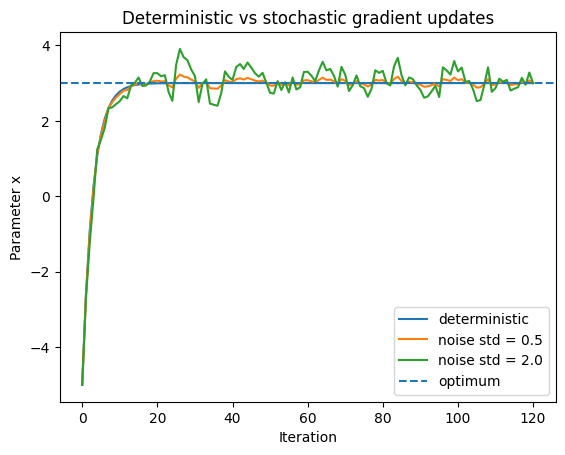

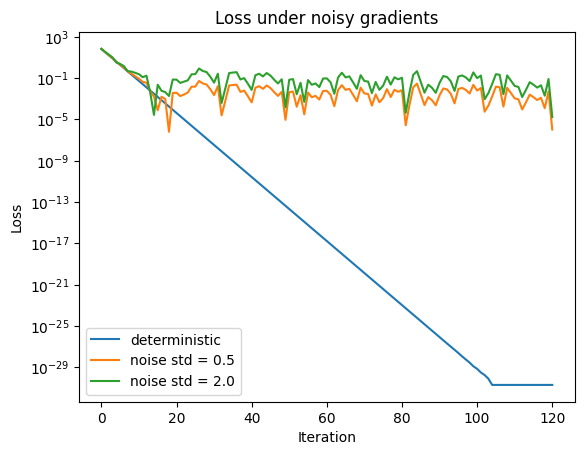

In [4]:

def sgd_noisy(x0, lr, steps, noise_std=0.0, seed=0):
    local_rng = np.random.default_rng(seed)
    xs = [x0]
    for _ in range(steps):
        x = xs[-1]
        g = grad_f(x) + local_rng.normal(0.0, noise_std)
        xs.append(x - lr * g)
    return np.array(xs)

x0 = -5.0
steps = 120
lr = 0.15

traj_det = sgd_noisy(x0, lr, steps, noise_std=0.0, seed=1)
traj_s1 = sgd_noisy(x0, lr, steps, noise_std=0.5, seed=1)
traj_s2 = sgd_noisy(x0, lr, steps, noise_std=2.0, seed=1)

plt.plot(traj_det, label="deterministic")
plt.plot(traj_s1, label="noise std = 0.5")
plt.plot(traj_s2, label="noise std = 2.0")
plt.axhline(3.0, linestyle="--", label="optimum")
plt.xlabel("Iteration")
plt.ylabel("Parameter x")
plt.title("Deterministic vs stochastic gradient updates")
plt.legend()
plt.show()

plt.plot([f(x) for x in traj_det], label="deterministic")
plt.plot([f(x) for x in traj_s1], label="noise std = 0.5")
plt.plot([f(x) for x in traj_s2], label="noise std = 2.0")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss under noisy gradients")
plt.legend()
plt.show()



### Key idea
SGD may not converge smoothly to one exact point.  
Instead, it often **hovers around** a good region because of gradient noise.

This is one reason why, in deep learning, people often talk about:
- convergence of the **training objective on average**,
- convergence to a **stationary region**,
- practical rather than exact convergence.

### Exercise
Try changing:
- `lr`
- `noise_std`
- `steps`

When does the method become too noisy to settle?



## 5. Exercise 3 — Bellman fixed-point convergence on a tiny MDP

For a fixed policy \(\pi\), the Bellman expectation update can be written as
\[
V_{k+1} = T^\pi V_k.
\]

In discounted problems, \(T^\pi\) is a **contraction** under standard conditions.  
That means repeated backups move us toward the unique fixed point \(V^\pi\).

We use a tiny 3-state Markov reward process:
- state 2 is terminal,
- discount factor \(\gamma = 0.9\).


Value iterates:
[[0.  0.  0. ]
 [0.  1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]
 [0.9 1.  0. ]]


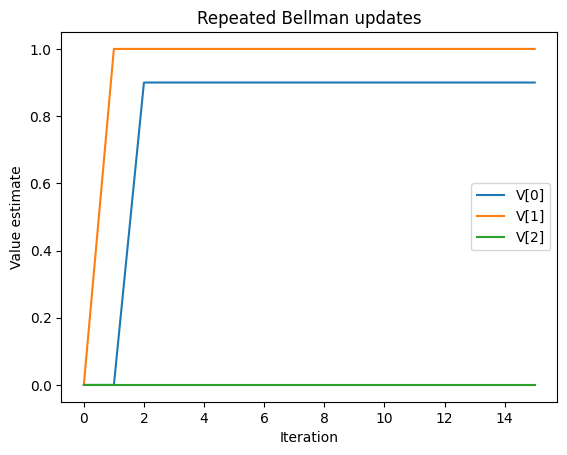

Fixed-point solution V* = [0.9 1.  0. ]
Last iterate = [0.9 1.  0. ]


In [5]:

P = np.array([
    [0.0, 1.0, 0.0],  # state 0 -> state 1
    [0.0, 0.0, 1.0],  # state 1 -> state 2
    [0.0, 0.0, 1.0],  # terminal stays terminal
])

r = np.array([0.0, 1.0, 0.0])   # reward received when leaving each state
gamma = 0.9

def bellman_update(V):
    return r + gamma * P @ V

V = np.zeros(3)
history = [V.copy()]
for _ in range(15):
    V = bellman_update(V)
    history.append(V.copy())

history = np.array(history)
print("Value iterates:")
print(history)

for s in range(3):
    plt.plot(history[:, s], label=f"V[{s}]")
plt.xlabel("Iteration")
plt.ylabel("Value estimate")
plt.title("Repeated Bellman updates")
plt.legend()
plt.show()

V_star = np.linalg.solve(np.eye(3) - gamma * P, r)
print("Fixed-point solution V* =", V_star)
print("Last iterate =", history[-1])



### Interpretation
The values should move toward the fixed point \(V^\pi\).  
This is the cleanest convergence picture in RL.

### Why this matters
Many RL algorithms are approximate versions of this idea:
- TD learning uses **sampled** Bellman updates,
- DQN uses **function approximation** plus sampled targets,
- actor–critic uses critics that learn from approximate Bellman relations.

### Exercise
Change:
- the reward vector `r`,
- the discount `gamma`,
- the transition matrix `P`.

How does the convergence speed change as \(\gamma\) gets closer to 1?



## 6. Exercise 4 — Tabular Q-learning on a tiny environment

Now we move from value prediction to control.

We use a very small 1D environment:
- states: \(0,1,2,3,4\),
- start in state 2,
- actions: left or right,
- reaching state 4 gives reward \(+1\),
- all other transitions give reward \(0\),
- episode ends at state 0 or 4.

This is small enough that we can inspect the whole Q-table.


Learned Q-table:
[[0.     0.    ]
 [0.     0.9013]
 [0.8532 0.95  ]
 [0.9021 1.    ]
 [0.     0.    ]]


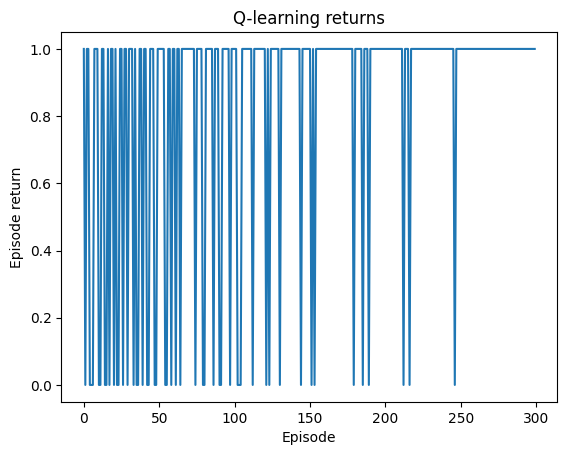

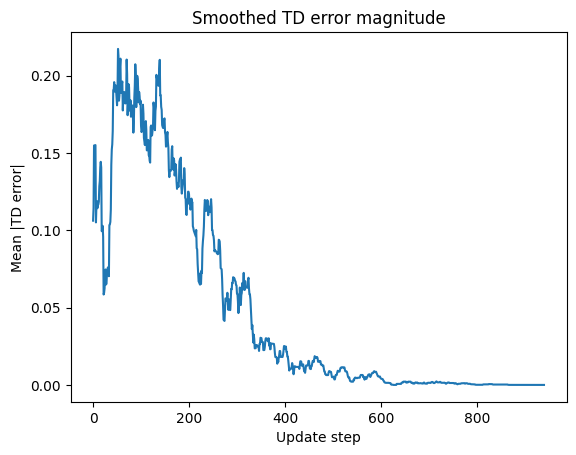

In [6]:

n_states = 5
actions = [0, 1]  # 0=left, 1=right

def step_env(state, action):
    if state in [0, 4]:
        return state, 0.0, True

    next_state = state - 1 if action == 0 else state + 1
    reward = 1.0 if next_state == 4 else 0.0
    done = next_state in [0, 4]
    return next_state, reward, done

def epsilon_greedy(Q, state, eps, rng):
    if rng.random() < eps:
        return rng.integers(0, 2)
    return int(np.argmax(Q[state]))

def q_learning(num_episodes=300, alpha=0.1, gamma=0.95, eps_start=1.0, eps_end=0.05):
    Q = np.zeros((n_states, 2))
    returns = []
    td_errors = []
    local_rng = np.random.default_rng(0)

    for ep in range(num_episodes):
        state = 2
        done = False
        G = 0.0
        eps = eps_start + (eps_end - eps_start) * (ep / max(1, num_episodes - 1))

        while not done:
            action = epsilon_greedy(Q, state, eps, local_rng)
            next_state, reward, done = step_env(state, action)
            target = reward if done else reward + gamma * np.max(Q[next_state])
            td = target - Q[state, action]
            Q[state, action] += alpha * td
            td_errors.append(abs(td))
            G += reward
            state = next_state

        returns.append(G)
    return Q, np.array(returns), np.array(td_errors)

Q, returns, td_errors = q_learning()

print("Learned Q-table:")
print(Q)

plt.plot(returns)
plt.xlabel("Episode")
plt.ylabel("Episode return")
plt.title("Q-learning returns")
plt.show()

window = 20
smoothed_td = np.convolve(td_errors, np.ones(window)/window, mode="valid")
plt.plot(smoothed_td)
plt.xlabel("Update step")
plt.ylabel("Mean |TD error|")
plt.title("Smoothed TD error magnitude")
plt.show()



### What to look for
A reasonable sign of convergence is:
- the policy becomes stable,
- TD errors become smaller on average,
- the Q-table stops changing much.

But this is still **empirical convergence**, not a proof.

### Exercise
Change:
- `alpha`,
- `gamma`,
- exploration schedule,
- number of episodes.

Questions:
1. What happens if \(\alpha\) is too large?
2. What happens if exploration disappears too early?
3. Does the return curve alone tell the whole story?



## 7. Exercise 5 — Why deep RL convergence is harder

In deep RL, targets often move while the model is learning.

A simplified analogy:
- prediction network tries to fit a target,
- but the target itself is slowly changing.

This happens in bootstrap methods because the target depends on learned estimates.

We simulate a moving-target regression problem.


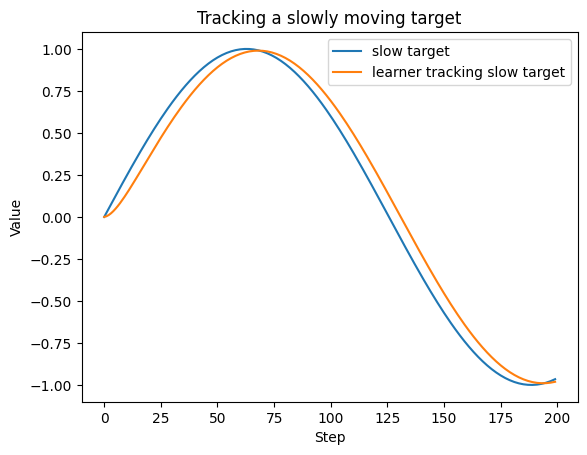

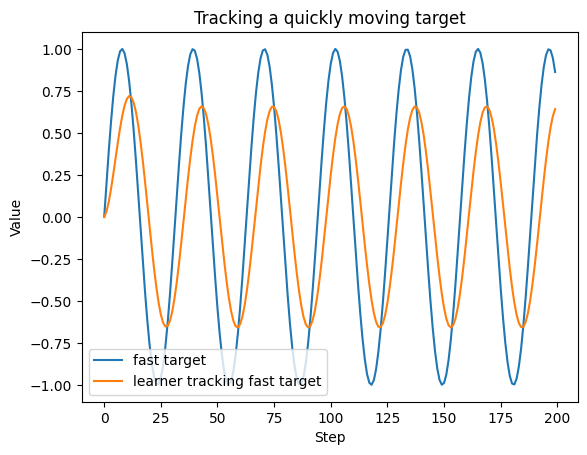

In [7]:

steps = 200
theta_hist_slow = []
theta_hist_fast = []

theta = 0.0
for t in range(steps):
    y_t = np.sin(t / 40.0)
    grad = 2 * (theta - y_t)
    theta -= 0.08 * grad
    theta_hist_slow.append(theta)

theta = 0.0
for t in range(steps):
    y_t = np.sin(t / 5.0)
    grad = 2 * (theta - y_t)
    theta -= 0.08 * grad
    theta_hist_fast.append(theta)

t = np.arange(steps)
plt.plot(np.sin(t / 40.0), label="slow target")
plt.plot(theta_hist_slow, label="learner tracking slow target")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("Tracking a slowly moving target")
plt.legend()
plt.show()

plt.plot(np.sin(t / 5.0), label="fast target")
plt.plot(theta_hist_fast, label="learner tracking fast target")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("Tracking a quickly moving target")
plt.legend()
plt.show()



### Discussion
When the target moves too fast, the learner may never settle.  
This is only an analogy, but it captures an important deep RL issue:

- the critic changes,
- the target changes,
- the data distribution changes,
- the policy changes.

This is one reason why deep RL usually offers fewer clean convergence guarantees than tabular RL.



## 8. Exercise 6 — A tiny two-agent non-stationarity experiment

In MARL, each agent sees a moving environment because the **other agents are also learning**.

We use a simple coordination game:

- both agents choose action 0 or 1,
- reward = 1 only if they match,
- otherwise reward = 0.

Each agent runs independent Q-learning.


Agent 1 Q-values: [0.6729 0.1372]
Agent 2 Q-values: [0.9562 0.119 ]


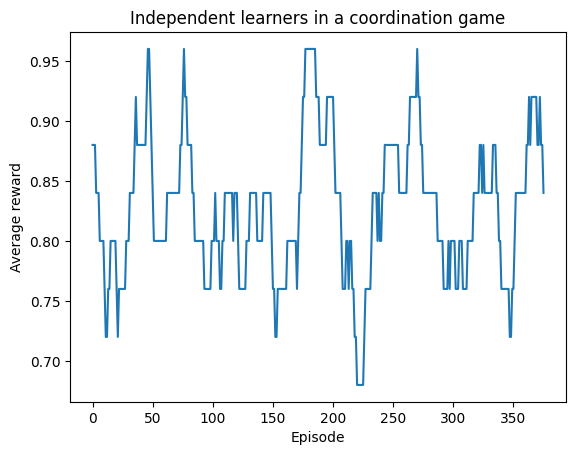

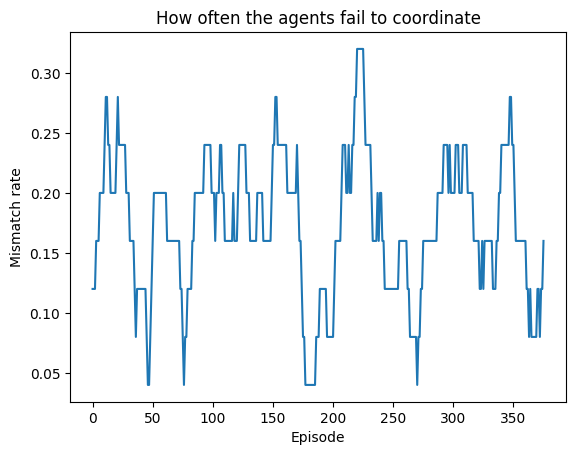

In [8]:

def marl_coordination(num_episodes=400, alpha=0.15, gamma=0.0, eps=0.2):
    Q1 = np.zeros(2)
    Q2 = np.zeros(2)
    local_rng = np.random.default_rng(3)
    rewards = []
    mismatches = []

    for _ in range(num_episodes):
        a1 = local_rng.integers(0, 2) if local_rng.random() < eps else int(np.argmax(Q1))
        a2 = local_rng.integers(0, 2) if local_rng.random() < eps else int(np.argmax(Q2))
        r = 1.0 if a1 == a2 else 0.0

        Q1[a1] += alpha * (r - Q1[a1])
        Q2[a2] += alpha * (r - Q2[a2])

        rewards.append(r)
        mismatches.append(int(a1 != a2))
    return Q1, Q2, np.array(rewards), np.array(mismatches)

Q1, Q2, rewards, mismatches = marl_coordination()
print("Agent 1 Q-values:", Q1)
print("Agent 2 Q-values:", Q2)

rolling = np.convolve(rewards, np.ones(25)/25, mode="valid")
plt.plot(rolling)
plt.xlabel("Episode")
plt.ylabel("Average reward")
plt.title("Independent learners in a coordination game")
plt.show()

rolling_mismatch = np.convolve(mismatches, np.ones(25)/25, mode="valid")
plt.plot(rolling_mismatch)
plt.xlabel("Episode")
plt.ylabel("Mismatch rate")
plt.title("How often the agents fail to coordinate")
plt.show()



### Why this matters
Even though the game is tiny, the learning signal can fluctuate because:
- agent 1 updates its policy,
- this changes the effective environment seen by agent 2,
- then agent 2 changes too.

This is one of the central reasons why **MARL convergence is harder** than single-agent RL convergence.

### Exercise
Try changing:
- `eps`,
- `alpha`,
- reward structure.

Can the agents always settle smoothly?



## 9. Short conceptual exercises

Write brief answers in the cells below.

### Q1
What is the difference between:
- convergence of the **loss**,
- convergence of the **parameters**,
- convergence of the **policy performance**?


In [9]:

answer_q2 = ""
print(answer_q2)



### Q2
Why do tabular discounted Bellman updates have cleaner convergence results than deep Q-learning?


In [10]:

answer_q3 = ""
print(answer_q3)



### Q3
Why is a decreasing TD error not, by itself, a complete proof that an RL algorithm has converged to the optimal policy?


In [11]:

answer_q4 = ""
print(answer_q4)



## 10. Mini-project suggestions

Choose one of the following and extend the notebook.

### Project A — Learning rate study
For the quadratic example, sweep over 20 learning rates and measure:
- final loss,
- number of iterations until the loss is below a threshold.

### Project B — TD vs Monte Carlo
Build a tiny episodic chain and compare:
- Monte Carlo prediction,
- TD(0) prediction,
- speed and variance of learning.

### Project C — Q-learning stability
Modify the tiny environment so rewards are noisy, then study how:
- learning rate,
- exploration,
- random seed
affect the final learned policy.

### Project D — MARL instability
Extend the coordination game into a competitive or mixed game and discuss why convergence becomes more difficult.



## 11. Final summary

This notebook illustrated the following points:

1. **Optimization convergence** depends strongly on learning rate.
2. **SGD** often converges noisily rather than perfectly smoothly.
3. **Bellman iteration** is a fixed-point process with a clean theory in discounted tabular settings.
4. **Q-learning** can look convergent empirically, but diagnosis requires more than one curve.
5. **Deep RL** is harder because targets, policies, and data distributions change during learning.
6. **MARL** is harder still because each learning agent makes the environment non-stationary for the others.

A good scientific habit is:

> Do not claim convergence from one figure alone.  
> Check stability, multiple seeds, policy quality, and whether the learned quantities are actually meaningful.
